In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

test = pd.read_csv("C:/Users/nikhi/OneDrive/Desktop/coding/engiwo 1/Credit-Risk-Loan-Default-Prediction/data/test_Y3wMUE5_7gLdaTN.csv")
train = pd.read_csv("C:/Users/nikhi/OneDrive/Desktop/coding/engiwo 1/Credit-Risk-Loan-Default-Prediction/data/train_u6lujuX_CVtuZ9i.csv")

train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
train.shape
train.info()
train.isnull().sum()
train['Loan_Status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [9]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

train['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)
test['LoanAmount'].fillna(test['LoanAmount'].median(), inplace=True)

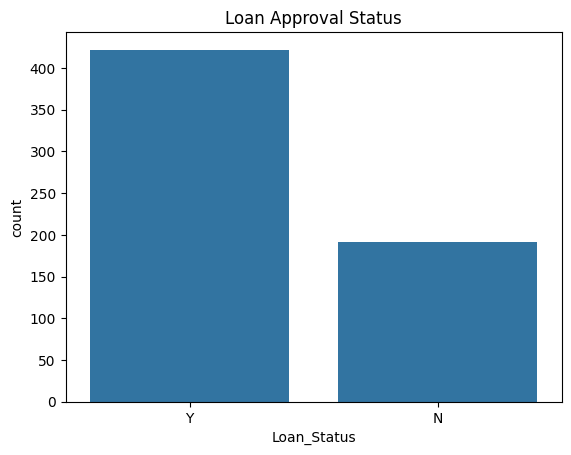

In [10]:
sns.countplot(x='Loan_Status', data=train)
plt.title("Loan Approval Status")
plt.show()

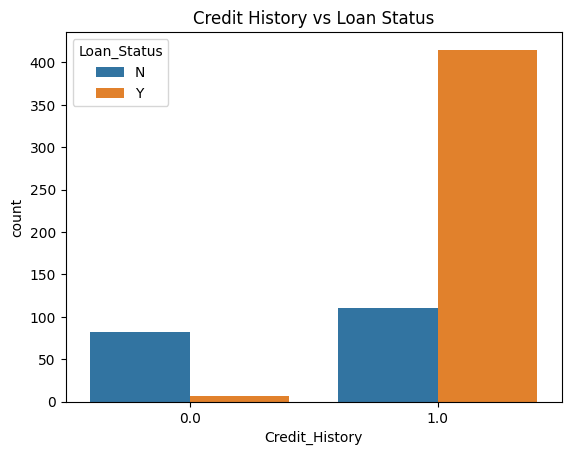

In [11]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=train)
plt.title("Credit History vs Loan Status")
plt.show()

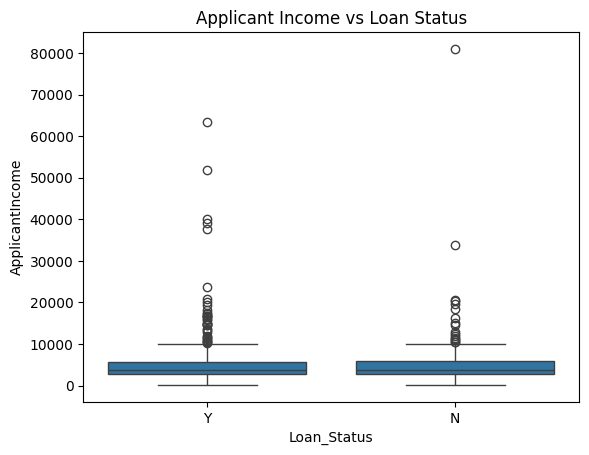

In [12]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=train)
plt.title("Applicant Income vs Loan Status")
plt.show()

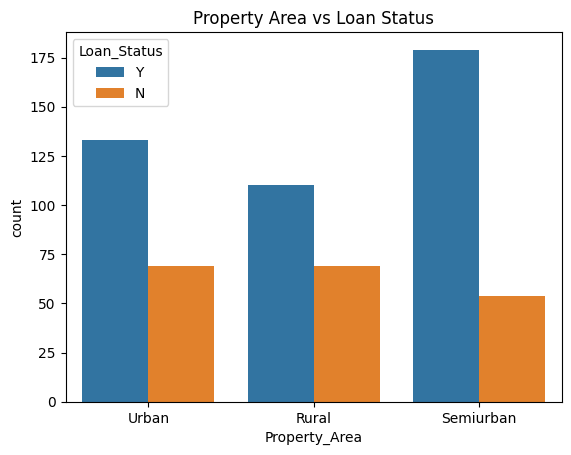

In [13]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=train)
plt.title("Property Area vs Loan Status")
plt.show()

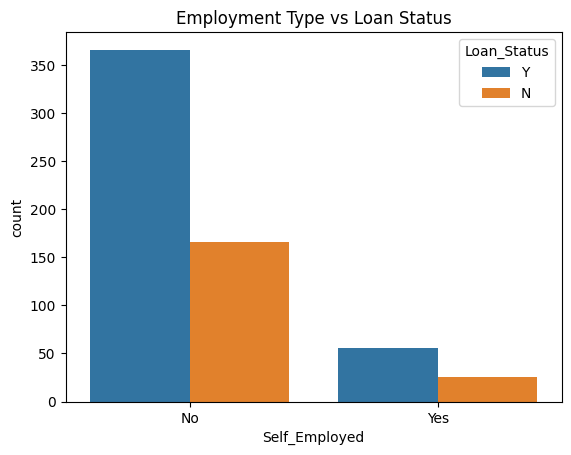

In [14]:
sns.countplot(x='Self_Employed', hue='Loan_Status', data=train)
plt.title("Employment Type vs Loan Status")
plt.show()

In [15]:
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']
test['Total_Income'] = test['ApplicantIncome'] + test['CoapplicantIncome']

train['Loan_to_Income_Ratio'] = train['LoanAmount'] / train['Total_Income']
test['Loan_to_Income_Ratio'] = test['LoanAmount'] / test['Total_Income']

train['EMI'] = train['LoanAmount'] / train['Loan_Amount_Term']
test['EMI'] = test['LoanAmount'] / test['Loan_Amount_Term']

train['EMI_to_Income_Ratio'] = train['EMI'] / train['Total_Income']
test['EMI_to_Income_Ratio'] = test['EMI'] / test['Total_Income']

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                    'Self_Employed', 'Property_Area']

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

train['Loan_Status'] = train['Loan_Status'].map({'N': 0, 'Y': 1})

In [17]:
X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = train['Loan_Status']

test_final = test.drop('Loan_ID', axis=1)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "ROC_AUC": roc_auc_score(y_val, pred)
    })

results_df = pd.DataFrame(results)
results_df

C:\Users\nikhi\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic Regression,0.788618,0.759615,0.9875,0.703052
1,Decision Tree,0.723577,0.780488,0.8000,0.690698
2,Random Forest,0.796748,0.789474,0.9375,0.736192


              precision    recall  f1-score   support

           0       0.82      0.53      0.65        43
           1       0.79      0.94      0.86        80

    accuracy                           0.80       123
   macro avg       0.81      0.74      0.75       123
weighted avg       0.80      0.80      0.78       123



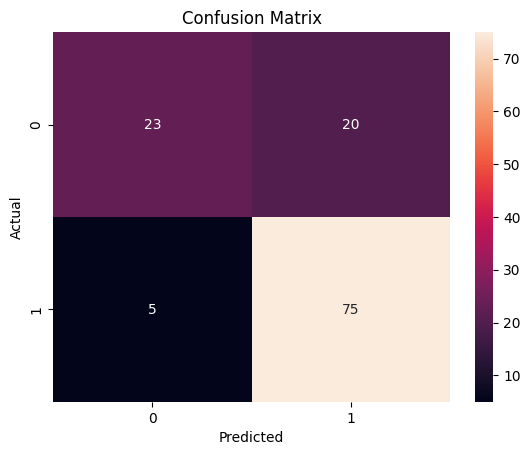

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_val)

print(classification_report(y_val, y_pred))

sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
9,Credit_History,0.239611
12,Loan_to_Income_Ratio,0.108773
11,Total_Income,0.103352
5,ApplicantIncome,0.092349
7,LoanAmount,0.090068
14,EMI_to_Income_Ratio,0.089663
13,EMI,0.079094
6,CoapplicantIncome,0.053620
10,Property_Area,0.034387
8,Loan_Amount_Term,0.028152


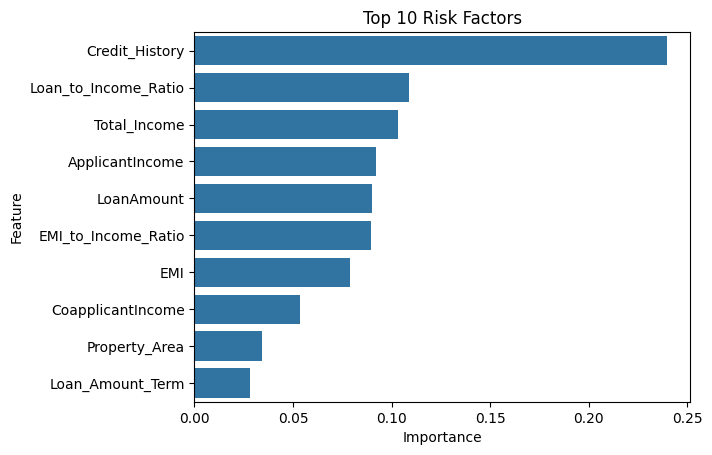

In [25]:
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top 10 Risk Factors")
plt.show()

In [26]:
final_predictions = best_model.predict(test_final)

submission = pd.DataFrame({
    'Loan_ID': test['Loan_ID'],
    'Loan_Status': final_predictions
})

submission['Loan_Status'] = submission['Loan_Status'].map({0: 'N', 1: 'Y'})

submission.to_csv("loan_default_predictions.csv", index=False)